# Wikispeedia Network Analysis: Paths Difficulty Analysis


In this notebook, we analyze the difficulty of challenges in Wikispeedia based on various measures, extracted from the Wikispeedia dataset, computed from the network or using external resources. 
we will confront 4 different difficulty measures:
- **Perceived Difficulty**: the difficulty of a challenge as rated by players, which is the most subjective measure.
- **Empirical Difficulty**: a difficulty score that combines average length, average duration, and failure rate.
- **Structural Difficulty**: the shortest path length between source and target nodes in the network.
- **Semantic Difficulty**: the semantic distance between source and target nodes, computed using a pre-trained FastText model.

## Import Libraries and Load Data

In [1]:

import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import unquote
np.random.seed(62)

#The notebook performs some long computations, that were saved in challenges_measures_final.csv
#To recreate the dataset from scratch, set CREATE_DATASET to True
CREATE_DATASET = False

In [2]:
#finished paths
df_path_fin= pd.read_csv('./data/datasets/paths_finished.tsv', sep='\t', skiprows=16, names=['player','timestamp','duration','path','rating'])
df_path_fin["path"] = df_path_fin["path"].apply(lambda x: unquote(x))
df_path_fin['source'] = df_path_fin['path'].apply(lambda x: x.split(';')[0])
df_path_fin['target'] = df_path_fin['path'].apply(lambda x: x.split(';')[-1])
# unfinished paths
df_path_unfin = pd.read_csv('./data/datasets/paths_unfinished.tsv', sep='\t', skiprows=17, names=['player','timestamp','duration','path', 'target', 'type'])
df_path_unfin["path"] = df_path_unfin["path"].apply(lambda x: unquote(x))
df_path_unfin['source'] = df_path_unfin['path'].apply(lambda x: x.split(';')[0])
df_path_unfin['target'] = df_path_unfin["target"].apply(lambda x: unquote(x))

display(df_path_fin.head())
display(df_path_unfin.head())

print(f"Finished paths: {len(df_path_fin)}")
print(f"Unfinished paths: {len(df_path_unfin)}")

,player,timestamp,duration,path,rating,source,target
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN,14th_century,African_slave_trade
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0,14th_century,African_slave_trade
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN,14th_century,African_slave_trade
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN,14th_century,Greece
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0,14th_century,John_F._Kennedy


,player,timestamp,duration,path,target,type,source
0,2426091a53125110,1297054935,1804,Obi-Wan_Kenobi,Microsoft,timeout,Obi-Wan_Kenobi
1,26141fd878806294,1297055651,1805,Julius_Caesar,Caracas,timeout,Julius_Caesar
2,2b015fb8181c48f2,1297090819,1818,Malawi;Democracy;Alexander_the_Great,First_Crusade,timeout,Malawi
3,53a53bc244e08a6a,1297094761,49,Paraguay,Mount_St._Helens,restart,Paraguay
4,53a53bc244e08a6a,1297099105,1808,Paraguay;Bolivia,Mount_St._Helens,timeout,Paraguay


Finished paths: 51318
Unfinished paths: 24875


## Data Manipulation

The dataset contains individual navigation paths taken by users while playing Wikispeedia.  
However, for our analysis, we are mainly interested in the challenges themselves, that is source and target article pairs.

To proceed, we need to create a new dataset that aggregates information based on each unique source-target pair.  
During this step, we also clean the data by removing invalid entries that could negatively impact the results.



### Cleaning Data

Some paths in the dataset show abnormal behavior, such as being excessively long or lasting more than 30 minutes.  
These outliers can bias our analysis and should be filtered out.

In particular, many unfinished paths ended due to a timeout without any clicks. These are likely cases where the user went AFK.

Note that we chose to keep the paths that were restarted without any clicks, as these likely reflect a conscious decision by the user to give up immediately.



In [3]:
df_path_fin['path_length'] = df_path_fin['path'].apply(lambda x: len(x.split(';')))
df_path_unfin['path_length'] = df_path_unfin['path'].apply(lambda x: len(x.split(';')))
#remove outliers
df_fin_clean = df_path_fin[
    (df_path_fin['path_length'] <= 50) &
    (df_path_fin['duration'] <= 1800) & #30min
    (df_path_fin['duration'] > 0) 
].copy()

print(f"Removed: {len(df_path_fin) - len(df_fin_clean)} ")
print(f"finished paths after filtering: {len(df_fin_clean)} ")

#remove outliers and afk paths
df_unfin_clean = df_path_unfin[
    (df_path_unfin['type'] != 'timeout') &
    (df_path_unfin['path_length'] > 1) &
    (df_path_unfin['path_length'] <= 50) &
    (df_path_unfin['duration'] <= 1800) &
    (df_path_unfin['duration'] > 0) 
].copy()

print(f"Removed: {len(df_path_unfin) - len(df_unfin_clean)} ")
print(f"Unfinished paths after filtering: {len(df_unfin_clean)}")


Removed: 170 
finished paths after filtering: 51148 
Removed: 12569 
Unfinished paths after filtering: 12306


In [4]:
#create comprehensive dataset with all metrics for each source-target pair (challenge)

if CREATE_DATASET:
    combined_df = pd.concat([df_fin_clean[['source', 'target']],df_unfin_clean[['source', 'target']]])
    #remove duplicates to get unique source-target pairs
    unique_pairs = combined_df.drop_duplicates()
    print("unique source-target pairs:", len(unique_pairs))

    challenges = []
    for _, row in unique_pairs.iterrows():
        source = row['source']
        target = row['target']

        finished_paths = df_fin_clean[(df_fin_clean['source'] == source) & (df_fin_clean['target'] == target)]
        unfinished_paths = df_unfin_clean[(df_unfin_clean['source'] == source) & (df_unfin_clean['target'] == target)]
        
        challenges.append({
            'source': source,
            'target': target,
            'avg_finished_duration': round(finished_paths['duration'].mean(), 2),
            'avg_finished_path_length': round(finished_paths['path_length'].mean(), 2),
            'avg_rating': round(finished_paths['rating'].mean() , 2),
            'failure_rate': round(len(unfinished_paths)/(len(unfinished_paths)+ len(finished_paths)),2),
            'avg_unfinished_duration': round(unfinished_paths['duration'].mean(), 2),
            'avg_unfinished_path_length': round(unfinished_paths['path_length'].mean(), 2),
        })

    df_challenges = pd.DataFrame(challenges)
    #save the dataset
    df_challenges.to_csv('./data/mydata/challenges_measures_final.csv', index=False)

#read dataset if it already exists
else:
    df_challenges = pd.read_csv('./data/mydata/challenges_measures_final.csv')

display(df_challenges.head())

,source,target,avg_finished_duration,avg_finished_path_length,avg_rating,failure_rate,avg_unfinished_duration,avg_unfinished_path_length,difficulty_score,shortest_path_length,semantic_distance
0,14th_century,African_slave_trade,130.67,7.33,3.00,0.40,674.5,9.50,0.17,3.0,0.33
1,14th_century,Greece,37.00,4.00,NaN,0.00,NaN,NaN,0.04,2.0,0.44
2,14th_century,John_F._Kennedy,142.50,6.50,3.00,0.00,NaN,NaN,0.08,3.0,0.30
3,14th_century,Fire,112.00,4.00,2.00,0.00,NaN,NaN,0.06,3.0,0.44
4,14th_century,Rainbow,181.93,7.44,2.62,0.34,124.0,6.36,0.17,3.0,0.44


## Correlation Analysis
Let's analyze the correlation between differnt difficulty indicators to get a better understanding of the data.

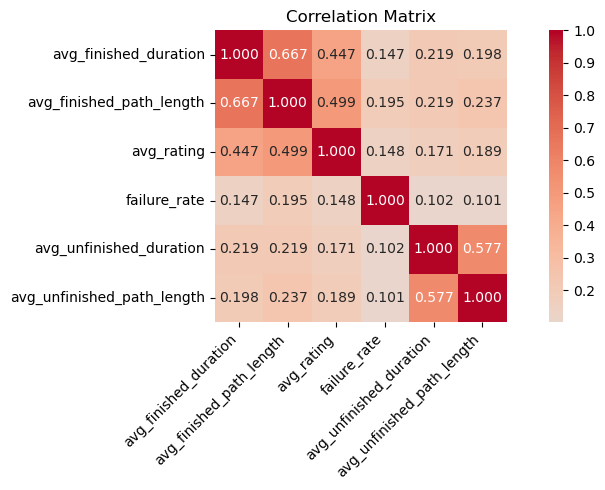

In [5]:
#plot correlation matrix
numeric_columns = ['avg_finished_duration', 'avg_finished_path_length', 'avg_rating', 
                  'failure_rate', 'avg_unfinished_duration', 'avg_unfinished_path_length']
correlation_matrix = df_challenges[numeric_columns].corr()

# Plotting
plt.figure(figsize=(9, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, square=True, fmt='.3f')
plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Results
As we can see from the correlation matrix, there are several observations we can make:
- **Avg path lenght** and **Avg duration** have a strong positive correlation (both in finished and unfinished paths). Obviously, clicking in more links takes more time. 
- **Average Rating** is correlated to both **Avg Finished Duration** and **Avg Finished Path Length**, indicating that players perceive paths as more difficult when they take longer to complete and make more clicks.
- **Failure Rate** is slightly positive correlated with all the other metrics, suggesting that if a ptah is more difficult for some players, there is a higher chance that other players will fail it.

## Composite Difficulty Score

Let's create a composite difficulty score based on different difficulty indicators.

Note that several attempts were made to find a formula that worked well and incorporated all relevant measures.  
For example, both the duration and length of finished and unfinished paths were included, weighted by success and failure rates.               
There were also many tests using the difficulty rating provided by users, but it appeared to be very inconsistent and missing in many cases.   
Missing values were filled using the average rating, but this approach skewed the distribution. Then a linear regression was tested to predict difficulty, but the model exhibited very low accuracy.

In the end, the difficulty score is defined as a simple weighted sum of the most important factors: the duration and length of finished paths and the failure rate.


$$DifficultyScore= 0.4 * AvgFinishedDuration + 0.4 * AvgFinishedPathlength + 0.2 * FailureRate $$



In [6]:
#Normalize measures to 0-1 scale
duration_norm = df_challenges['avg_finished_duration'] / df_challenges['avg_finished_duration'].max()
length_norm = df_challenges['avg_finished_path_length'] / df_challenges['avg_finished_path_length'].max()
failure_rate = df_challenges['failure_rate']  
#create difficulty score 
df_challenges['difficulty_score'] = round(0.4 * duration_norm + 0.4 * length_norm + 0.2 * failure_rate,2)
if CREATE_DATASET:
    df_challenges.to_csv('./data/mydata/challenges_measures_final.csv', index=False)

In [7]:
correlation_cols = ['avg_finished_duration', 'avg_finished_path_length', 'avg_rating', 
                   'failure_rate', 'avg_unfinished_duration', 'avg_unfinished_path_length', 'difficulty_score']
corr_matrix = df_challenges[correlation_cols].corr()
print("Correaltion with difficulty:")
print(corr_matrix["difficulty_score"])

Correaltion with difficulty:
avg_finished_duration         0.845820
avg_finished_path_length      0.849959
avg_rating                    0.496498
failure_rate                  0.535033
avg_unfinished_duration       0.244317
avg_unfinished_path_length    0.245888
difficulty_score              1.000000
Name: difficulty_score, dtype: float64


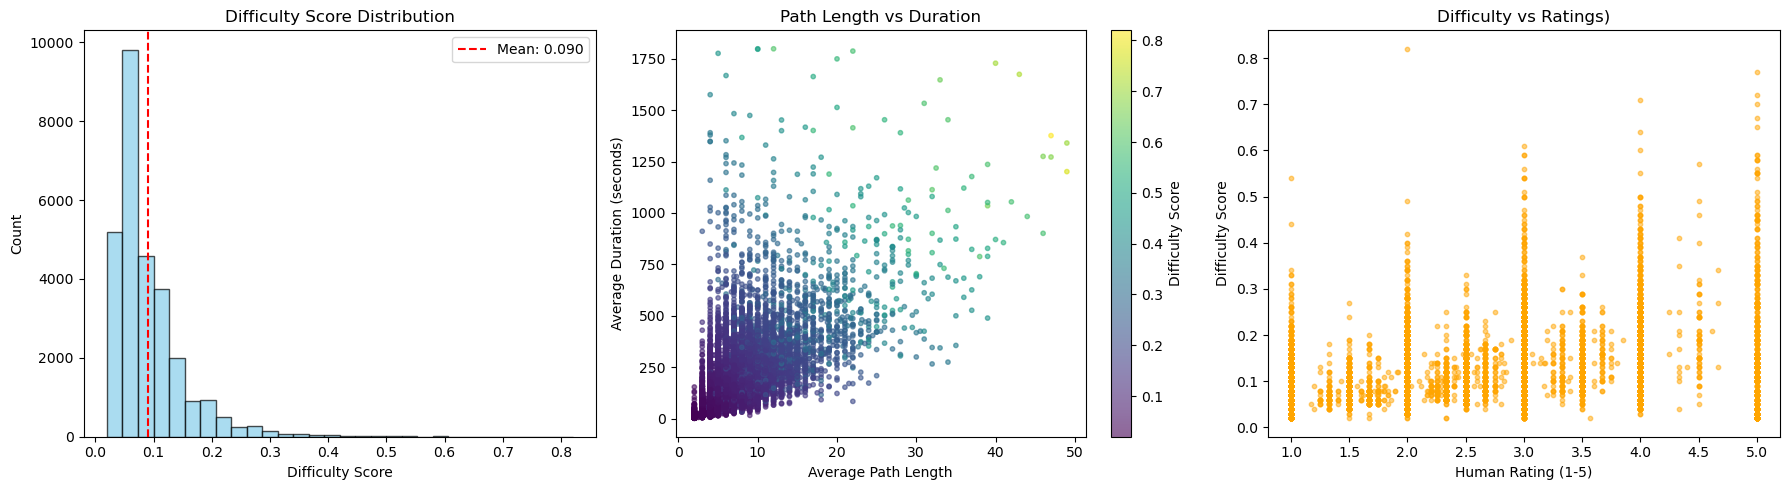

In [8]:
#Plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

#ddistribution of difficulty scores
ax1.hist(df_challenges['difficulty_score'], bins=30, alpha=0.7, edgecolor='black', color='skyblue')
ax1.axvline(df_challenges['difficulty_score'].mean(), color='red', linestyle='--', 
           label=f'Mean: {df_challenges["difficulty_score"].mean():.3f}')
ax1.set_xlabel('Difficulty Score')
ax1.set_ylabel('Count')
ax1.set_title('Difficulty Score Distribution')
ax1.legend()

#path length vs duration colored by difficulty score
scatter = ax2.scatter(df_challenges['avg_finished_path_length'], df_challenges['avg_finished_duration'], 
                     c=df_challenges['difficulty_score'], cmap='viridis', alpha=0.6, s=10)
ax2.set_xlabel('Average Path Length')
ax2.set_ylabel('Average Duration (seconds)')
ax2.set_title('Path Length vs Duration')
plt.colorbar(scatter, ax=ax2, label='Difficulty Score')

#difficulty score vs ratings
rated_paths = df_challenges[df_challenges['avg_rating'].notna()]
ax3.scatter(rated_paths['avg_rating'], rated_paths['difficulty_score'], 
           alpha=0.5, s=10, color='orange')
ax3.set_xlabel('Human Rating (1-5)')
ax3.set_ylabel('Difficulty Score')
ax3.set_title(f'Difficulty vs Ratings)')

plt.tight_layout()
plt.show()

### Results

As we can see, the difficulty score is well correlated with all the difficulty indicators.  
Its distribution is highly skewed, with most paths having a low difficulty score and only a few paths being very difficult.  
The plot of difficulty score vs user rating appears quite noisy, due to the subjective nature of the ratings, but it still reveals a positive correlation


### Most Difficult and Easiest Challenges

In [9]:
print("## TOP 5 most difficult paths")
top_10 = df_challenges.sort_values("difficulty_score", ascending=False).head(5).reset_index(drop=True)
for i, row in top_10.iterrows():
    print(f"{i+1:2d}. {row['source']} -> {row['target']} ({row['difficulty_score']:.3f})")

print("\n## TOP 5 easiest paths")
bottom_10 = df_challenges.sort_values("difficulty_score", ascending=True).head(5).reset_index(drop=True)
for i, row in bottom_10.iterrows():
    print(f"{i+1:2d}. {row['source']} -> {row['target']} ({row['difficulty_score']:.3f})")


## TOP 5 most difficult paths
 1. Comet_Hale-Bopp -> Walt_Disney (0.820)
 2. Global_warming -> Dik-dik (0.770)
 3. Voting -> Library_of_Alexandria (0.720)
 4. Lake_Burley_Griffin -> Antonio_Vivaldi (0.710)
 5. Theatre -> Jackdaw (0.700)

## TOP 5 easiest paths
 1. Bird_migration -> Blackbird (0.020)
 2. Canada -> Canadian_football (0.020)
 3. Carbon -> Diamond (0.020)
 4. Carbon -> Periodic_table (0.020)
 5. Neoclassicism -> Russia (0.020)


---

## Shortest Path Analysis
Let's calculate the shortest path between each source and target word, to analyze structurally difficult challenges, and see if they are also difficult in real challenges.

In [10]:
#load data
df_articles = pd.read_csv('./data/datasets/articles.tsv', sep='\t', skiprows=12, names=['article'])
df_articles["article"] = df_articles["article"].apply(lambda x: unquote(x))

df_links = pd.read_csv('./data/datasets/links.tsv', sep='\t', skiprows=12, names=['source', 'target'])
df_links["source"] = df_links["source"].apply(lambda x: unquote(x))
df_links["target"] = df_links["target"].apply(lambda x: unquote(x))

df_challenges= pd.read_csv('./data/mydata/challenges_measures_final.csv')

#create graph
G = nx.DiGraph()
G.add_nodes_from(df_articles["article"])
G.add_edges_from(zip(df_links["source"], df_links["target"]))

In [11]:
for idx, row in df_challenges.iterrows():
    source = row['source']
    target = row['target']
    try:
        shortest_path_length = nx.shortest_path_length(G, source=source, target=target)
    except Exception as e: #path not found 
        shortest_path_length = None
    df_challenges.loc[idx, 'shortest_path_length'] = shortest_path_length

if CREATE_DATASET:
    df_challenges.to_csv('./data/mydata/challenges_measures_final.csv', index=False)

### Most shortest and longest shortest paths

In [12]:
print("## TOP 5 longest shortest paths")
top_10 = df_challenges.sort_values("shortest_path_length", ascending=False).head(5).reset_index(drop=True)
for i, row in top_10.iterrows():
    print(f"{i+1:2d}. {row['source']} -> {row['target']} ({row['shortest_path_length']})")

print("\n## TOP 5 shortest shortest paths")
bottom_10 = df_challenges.sort_values("shortest_path_length", ascending=True).head(5).reset_index(drop=True)
for i, row in bottom_10.iterrows():
    print(f"{i+1:2d}. {row['source']} -> {row['target']} ({row['shortest_path_length']})")

## TOP 5 longest shortest paths
 1. Blue_Wildebeest -> Tufted_Duck (7.0)
 2. Link_(The_Legend_of_Zelda) -> Black_panther (7.0)
 3. Camarasaurus -> Black_panther (7.0)
 4. Ars_moriendi -> Black_panther (7.0)
 5. Malaspina_Glacier -> Issyk_Kul (7.0)

## TOP 5 shortest shortest paths
 1. United_States -> Florida (1.0)
 2. Horatio_Nelson,_1st_Viscount_Nelson -> Order_of_the_Bath (1.0)
 3. Democracy -> Africa (1.0)
 4. Dinosaur -> China (1.0)
 5. Democracy -> Marxism (1.0)


### Impossible Challenges
Let's check if some unfortunate players encountered challenges with no possible path in the network.

In [13]:
#check if some challenges are impossible
impossible_challenges = df_challenges[df_challenges['shortest_path_length'].isna()]
if not impossible_challenges.empty:
    print("## Challenges with no path found:")
    for _, row in impossible_challenges.iterrows():
        print(f"- {row['source']} -> {row['target']}")
else:
    print("## All challenges have a valid path")

## Challenges with no path found:
- Bird -> Wikipedia_Text_of_the_GNU_Free_Documentation_License
- Black_pepper -> Long_peper
- Star_Trek -> Test
- Watercolor_painting -> Podcast
- Andrew_Jackson -> Christmas
- Lavender -> Charlottes_web
- Coin -> Macedonia
- Beijing -> Usa
- Diamond -> The_Rock
- Anne_Frank -> Final_Fantasy_(video_game)
- Hymenoptera -> Portuguese_Communist_Party
- Tripoli -> Bogota
- Europe -> Rat
- Pakistan -> Kashmir
- Switzerland -> Christmas


---

## Semantic Analysis
Let's analyze the semantic similarity between the source and target words of each challenge, to see if there is a correlation between semantic distance and difficulty.

For this task we will use **FastText**, a word embedding model developed by Facebook. It extends Word2Vec by representing words as bags of character n-grams, alowing it to capture subword information, to generate embeddings for unknown words by composing them from the embeddings of their constituent n-grams. 

FastText has been trained on large corpora, including Wikipedia, and provides pre-trained word vectors 

By calculating the cosine similarity between the embeddings of source and target words, we can quantify their semantic proximity.


In [14]:
import fasttext
import fasttext.util
# download and load the FastText model
fasttext.util.download_model('en', if_exists='ignore') 
model = fasttext.load_model('cc.en.300.bin')
df_challenges= pd.read_csv('./data/mydata/challenges_measures_final.csv')

In [15]:
# semantic distance calculation
def get_semantic_distance(article1, article2):
    vec1 = model.get_word_vector(article1.replace('_', ' '))
    vec2 = model.get_word_vector(article2.replace('_', ' '))
    cosine_sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
    return (1 - cosine_sim) / 2 # normalize [0, 1] 

for idx, row in df_challenges.iterrows():
    source = row['source']
    target = row['target']
    try:
        semantic_distance = get_semantic_distance(source, target)
    except Exception as e:
        semantic_distance = None
    df_challenges.loc[idx, 'semantic_distance'] = round(semantic_distance,2)

if CREATE_DATASET:
    df_challenges.to_csv('./data/mydata/challenges_measures_final.csv', index=False)

### Most semantically distant and closest paths

In [16]:
print("## TOP 5 most semantically distant paths")
top_10 = df_challenges.sort_values("semantic_distance", ascending=False).head(5).reset_index(drop=True)
for i, row in top_10.iterrows():
    print(f"{i+1:2d}. {row['source']} -> {row['target']} ({row['semantic_distance']:.3f})")

print("\n## TOP 5 most semantically close paths")
bottom_10 = df_challenges.sort_values("semantic_distance", ascending=True).head(5).reset_index(drop=True)
for i, row in bottom_10.iterrows():
    print(f"{i+1:2d}. {row['source']} -> {row['target']} ({row['semantic_distance']:.3f})")

## TOP 5 most semantically distant paths
 1. Blade_Runner -> Red_Sea (0.610)
 2. Leo_Tolstoy -> Red_Sea (0.570)
 3. Cheetah -> C++ (0.560)
 4. Dundee -> Emperor_Penguin (0.560)
 5. Issyk_Kul -> ITunes (0.560)

## TOP 5 most semantically close paths
 1. North_America -> South_America (0.020)
 2. 9th_century -> 8th_century (0.030)
 3. Tropical_Storm_Zeta_(2005) -> Tropical_Storm_Delta_(2005) (0.030)
 4. World_War_I -> World_War_II (0.030)
 5. North_Korea -> South_Korea (0.040)


--- 
## Final Comparison
Let's compare the difficulty of challenges based on difficulty_score, shortest path length, human rating, and semantic distance.

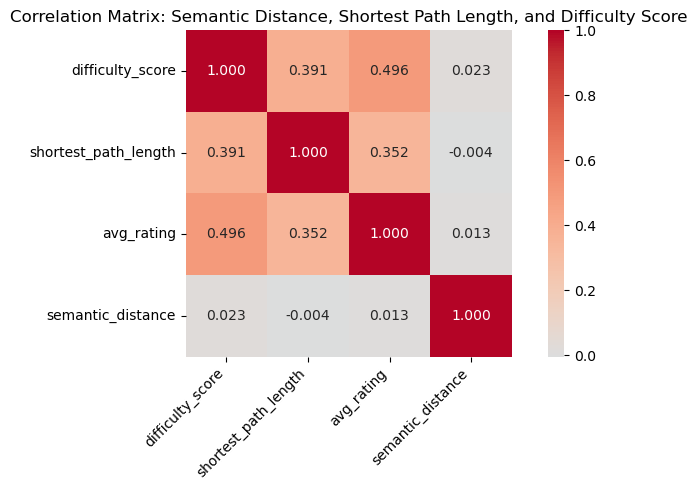

In [17]:
#correlation matrix plot between semantic distance, shortest path length, and difficulty score
df_challenges= pd.read_csv('./data/mydata/challenges_measures_final.csv')
correlation_cols = ['difficulty_score','shortest_path_length','avg_rating','semantic_distance']
correlation_matrix = df_challenges[correlation_cols].corr()
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, square=True, fmt='.3f')
plt.title('Correlation Matrix: Semantic Distance, Shortest Path Length, and Difficulty Score')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusions

As we can see, there are several factors that contribute to the difficulty of challenges in Wikispeedia.

- **Difficulty Score** is moderately correlated with shortest path length and human rating, indicating that challenges that are structurally more difficult take longer to complete and thus are perceived as more difficult by players.

- **Semantic Distance** is not correlated with any of the other difficulty indicators, suggesting that challenges with semantically distant words are not necessarily more difficult.

This may seem counterintuitive at first, but it makes sense because Wikipedia links are based on encyclopedic relevance, not just semantic similarity. For example, *"Banana"* and *"Apple"* are semantically similar, yet they are not linked in Wikipedia. When writing a Wikipedia page, links are generally not used to list synonyms, but rather to reference related concepts that have various types of relationships beyond simple similarity.

Furthermore, semantic distance is symmetric, whereas the difficulty of a challenge is not, since the network is directed. For instance, *"World_War_I"* is very close to *"World_War_II"*, but there is only a link from *"World_War_I"* to *"World_War_II"*, not viceversa